In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [11]:
design_path = 'EGFR_designs_uncond_composite.csv'
designs = pd.read_csv(design_path)
designs['design_info'] = designs['design_info'].str.split(',').str[0].str.split(':').str[-1].str.strip()
designs.head()

,Design,ppi-pred,ppi-probability,predicted-pKd,design_info,esm_pll_total,esm_pll_averaged,esmfold_plddt,composite_score
0,QVQLQQSGPGLVQPGQSLSITCTVSGFSLTNYDVHWVRQSPGKGLE...,1,0.9990,8.9226,0.08,-286.494759,-1.188775,0.746589,5.598075
1,QVQLQQSGPGVVQPGQSLSITCGVSGFSLTNNGVHWVRQAPGKGLE...,1,0.9990,9.0090,0.12,-291.622010,-1.210050,0.747863,5.562379
2,QVQLQQSGPGLVQPGQSLSITCTVSGFSLTNYGVHWVRQSPGKGLE...,1,0.9991,8.9762,0.03,-288.920169,-1.198839,0.742395,5.553611
3,QVQLQQSGPGLVQPGQSLSITCTVSGFSLTNYGVAWVRQSPGKGLE...,1,0.9994,9.0582,0.05,-294.138681,-1.220492,0.745370,5.528637
4,QVQLQQSGPGLVQPGQSLSITCTVSGFSLTNYGVHWVRQSPGKGLE...,1,0.9992,9.0028,0.1,-289.214807,-1.200061,0.736730,5.522489


In [15]:
egfr = pd.read_csv('egfr.csv')
print(len(egfr))
print(egfr.head())

# Drop the 'replicate' column
egfr.drop(columns=['replicate'], inplace=True)

# Identify non-numeric columns (excluding the groupby key)
non_numeric_cols = egfr.select_dtypes(exclude=[np.number]).columns.tolist()
non_numeric_cols = [col for col in non_numeric_cols if col != 'name']

# Group by 'name', aggregate numeric columns by mean, and keep non-numeric columns if all values are the same within the group
def keep_if_unique(series):
    unique_vals = series.unique()
    if len(unique_vals) == 1:
        return unique_vals[0]
    else:
        return np.nan

agg_dict = {col: keep_if_unique for col in non_numeric_cols}
# Add mean aggregation for numeric columns
for col in egfr.select_dtypes(include=[np.number]).columns:
    agg_dict[col] = 'mean'

egfr = egfr.groupby('name', as_index=False).agg(agg_dict)

print(len(egfr))
egfr.head()


40
          name  replicate expression  binding            kd            kon  \
0   dsm_egfr_1          1       none  unknown           NaN            NaN   
1   dsm_egfr_1          2       none  unknown           NaN            NaN   
2  dsm_egfr_10          1        low     true  6.278405e-10  641566.344547   
3  dsm_egfr_10          2        low     true  1.094538e-09  293366.812895   
4  dsm_egfr_11          1        low     true  3.573111e-09  230830.305092   

       koff                                           sequence  \
0       NaN  QVQLQQSGSGLVQPSQSLSIGCTVDNGSYTNYGVAWVRQSPGKGLE...   
1       NaN  QVQLQQSGSGLVQPSQSLSIGCTVDNGSYTNYGVAWVRQSPGKGLE...   
2  0.000403  QVQLQQSGPGLVQPSQSLSITCTVSGFSLTNYGVHWVRQSPGKGLE...   
3  0.000321  QVQLQQSGPGLVQPSQSLSITCTVSGFSLTNYGVHWVRQSPGKGLE...   
4  0.000825  QVQLQQSGPGLVQPSQTLSITCTVSGFSLTNYGVHWVRQSPGKGLE...   

  binding_strength confidence  
0          unknown        NaN  
1          unknown        NaN  
2           strong        low  
3  

,name,expression,binding,sequence,binding_strength,confidence,kd,kon,koff
0,dsm_egfr_1,none,unknown,QVQLQQSGSGLVQPSQSLSIGCTVDNGSYTNYGVAWVRQSPGKGLE...,unknown,NaN,NaN,NaN,NaN
1,dsm_egfr_10,low,true,QVQLQQSGPGLVQPSQSLSITCTVSGFSLTNYGVHWVRQSPGKGLE...,strong,NaN,8.611894e-10,467466.578721,0.000362
2,dsm_egfr_11,low,true,QVQLQQSGPGLVQPSQTLSITCTVSGFSLTNYGVHWVRQSPGKGLE...,strong,low,2.423023e-09,483260.507597,0.000881
3,dsm_egfr_12,NaN,true,QVQLQQSGPGLVQPSQSLTLTCTVSGFSLTNYGVHWVRQAPGKGLE...,strong,high,2.449604e-09,495266.498040,0.001181
4,dsm_egfr_13,low,false,QVQLQQSGPGLVQPGQSLSITCTVSGFSLTNYDVHWVRQSPGKGLE...,none,NaN,NaN,NaN,NaN


In [16]:
egfr['pkd'] = -np.log10(egfr['kd'])
# sort by pkd, largest at top
egfr = egfr.sort_values(by='pkd', ascending=False)
egfr.head()

,name,expression,binding,sequence,binding_strength,confidence,kd,kon,koff,pkd
1,dsm_egfr_10,low,true,QVQLQQSGPGLVQPSQSLSITCTVSGFSLTNYGVHWVRQSPGKGLE...,strong,NaN,8.611894e-10,467466.578721,0.000362,9.064901
7,dsm_egfr_16,low,true,QVQLQQSGPGLVQPSQSLSITCTVSGFSLTNYGVHWVRQSPGKGLE...,strong,low,1.783601e-09,366746.074487,0.000654,8.748702
9,dsm_egfr_18,medium,true,QVQLQQSGPVLVQPSQSLSITCTVSGFSLTNYGVHWVRQSAGKGLE...,strong,high,2.147987e-09,491020.218388,0.001048,8.667968
2,dsm_egfr_11,low,true,QVQLQQSGPGLVQPSQTLSITCTVSGFSLTNYGVHWVRQSPGKGLE...,strong,low,2.423023e-09,483260.507597,0.000881,8.615642
3,dsm_egfr_12,NaN,true,QVQLQQSGPGLVQPSQSLTLTCTVSGFSLTNYGVHWVRQAPGKGLE...,strong,high,2.449604e-09,495266.498040,0.001181,8.610904


In [17]:
# map sequence to info in designs df
# columns ppi-probability, predicted-pkd, design_info, esm_pll_averaged, esmfold_plddt, composite_score
# for design info, we need to apply .split(',')[0].split(':')[-1].strip()

# Create a mapping dictionary from designs dataframe
design_mapping = {}
for idx, row in designs.iterrows():
    seq = row['Design']
    design_mapping[seq] = {
        'ppi-probability': row['ppi-probability'],
        'predicted-pkd': row['predicted-pKd'],
        'design_info': row['design_info'],
        'esm_pll_averaged': row['esm_pll_averaged'],
        'esmfold_plddt': row['esmfold_plddt'],
        'composite_score': row['composite_score']
    }

print(len(design_mapping))

# Add new columns to egfr dataframe
egfr['ppi-probability'] = egfr['sequence'].map(lambda x: design_mapping.get(x, {}).get('ppi-probability', np.nan))
egfr['predicted-pkd'] = egfr['sequence'].map(lambda x: design_mapping.get(x, {}).get('predicted-pkd', np.nan))
egfr['mask-rate'] = egfr['sequence'].map(lambda x: design_mapping.get(x, {}).get('design_info', np.nan))
egfr['esm_pll_averaged'] = egfr['sequence'].map(lambda x: design_mapping.get(x, {}).get('esm_pll_averaged', np.nan))
egfr['esmfold_plddt'] = egfr['sequence'].map(lambda x: design_mapping.get(x, {}).get('esmfold_plddt', np.nan))
egfr['composite_score'] = egfr['sequence'].map(lambda x: design_mapping.get(x, {}).get('composite_score', np.nan))
# Display the updated dataframe
egfr.head()

999


,name,expression,binding,sequence,binding_strength,confidence,kd,kon,koff,pkd,ppi-probability,predicted-pkd,mask-rate,esm_pll_averaged,esmfold_plddt,composite_score
1,dsm_egfr_10,low,true,QVQLQQSGPGLVQPSQSLSITCTVSGFSLTNYGVHWVRQSPGKGLE...,strong,NaN,8.611894e-10,467466.578721,0.000362,9.064901,0.9991,8.9364,0.02,-1.225115,0.751387,5.475937
7,dsm_egfr_16,low,true,QVQLQQSGPGLVQPSQSLSITCTVSGFSLTNYGVHWVRQSPGKGLE...,strong,low,1.783601e-09,366746.074487,0.000654,8.748702,0.9983,8.9469,0.05,-1.259067,0.752840,5.340572
9,dsm_egfr_18,medium,true,QVQLQQSGPVLVQPSQSLSITCTVSGFSLTNYGVHWVRQSAGKGLE...,strong,high,2.147987e-09,491020.218388,0.001048,8.667968,0.9988,8.9357,0.06,-1.253375,0.751183,5.348989
2,dsm_egfr_11,low,true,QVQLQQSGPGLVQPSQTLSITCTVSGFSLTNYGVHWVRQSPGKGLE...,strong,low,2.423023e-09,483260.507597,0.000881,8.615642,0.9990,8.9318,0.02,-1.253149,0.751929,5.354007
3,dsm_egfr_12,NaN,true,QVQLQQSGPGLVQPSQSLTLTCTVSGFSLTNYGVHWVRQAPGKGLE...,strong,high,2.449604e-09,495266.498040,0.001181,8.610904,0.9992,8.9876,0.08,-1.226571,0.742273,5.434593


In [18]:
# manually add template

template = {
    'name': 'template',
    'sequence': 'QVQLQQSGPGLVQPSQSLSITCTVSGFSLTNYGVHWVRQSPGKGLEWLGVIWSGGNTDYNTPFTSRLSISRDTSKSQVFFKMNSLQTDDTAIYYCARALTYYDYEFAYWGQGTLVTVSAGGGGSGGGGSGGGGSDILLTQSPVILSVSPGERVSFSCRASQSIGTNIHWYQQRTNGSPKLLIRYASESISGIPSRFSGSGSGTDFTLSINSVDPEDIADYYCQQNNNWPTTFGAGTKLELK',
    'ppi-probability': 0.9992,
    'predicted-pkd': 8.8306,
    'pkd': 8.9182,
    'mask-rate': 0.0
}

egfr = pd.concat([egfr, pd.DataFrame([template])], ignore_index=True)
egfr.head()

,name,expression,binding,sequence,binding_strength,confidence,kd,kon,koff,pkd,ppi-probability,predicted-pkd,mask-rate,esm_pll_averaged,esmfold_plddt,composite_score
0,dsm_egfr_10,low,true,QVQLQQSGPGLVQPSQSLSITCTVSGFSLTNYGVHWVRQSPGKGLE...,strong,NaN,8.611894e-10,467466.578721,0.000362,9.064901,0.9991,8.9364,0.02,-1.225115,0.751387,5.475937
1,dsm_egfr_16,low,true,QVQLQQSGPGLVQPSQSLSITCTVSGFSLTNYGVHWVRQSPGKGLE...,strong,low,1.783601e-09,366746.074487,0.000654,8.748702,0.9983,8.9469,0.05,-1.259067,0.752840,5.340572
2,dsm_egfr_18,medium,true,QVQLQQSGPVLVQPSQSLSITCTVSGFSLTNYGVHWVRQSAGKGLE...,strong,high,2.147987e-09,491020.218388,0.001048,8.667968,0.9988,8.9357,0.06,-1.253375,0.751183,5.348989
3,dsm_egfr_11,low,true,QVQLQQSGPGLVQPSQTLSITCTVSGFSLTNYGVHWVRQSPGKGLE...,strong,low,2.423023e-09,483260.507597,0.000881,8.615642,0.9990,8.9318,0.02,-1.253149,0.751929,5.354007
4,dsm_egfr_12,NaN,true,QVQLQQSGPGLVQPSQSLTLTCTVSGFSLTNYGVHWVRQAPGKGLE...,strong,high,2.449604e-09,495266.498040,0.001181,8.610904,0.9992,8.9876,0.08,-1.226571,0.742273,5.434593


In [19]:
egfr.to_csv('egfr_with_designs.csv', index=False)

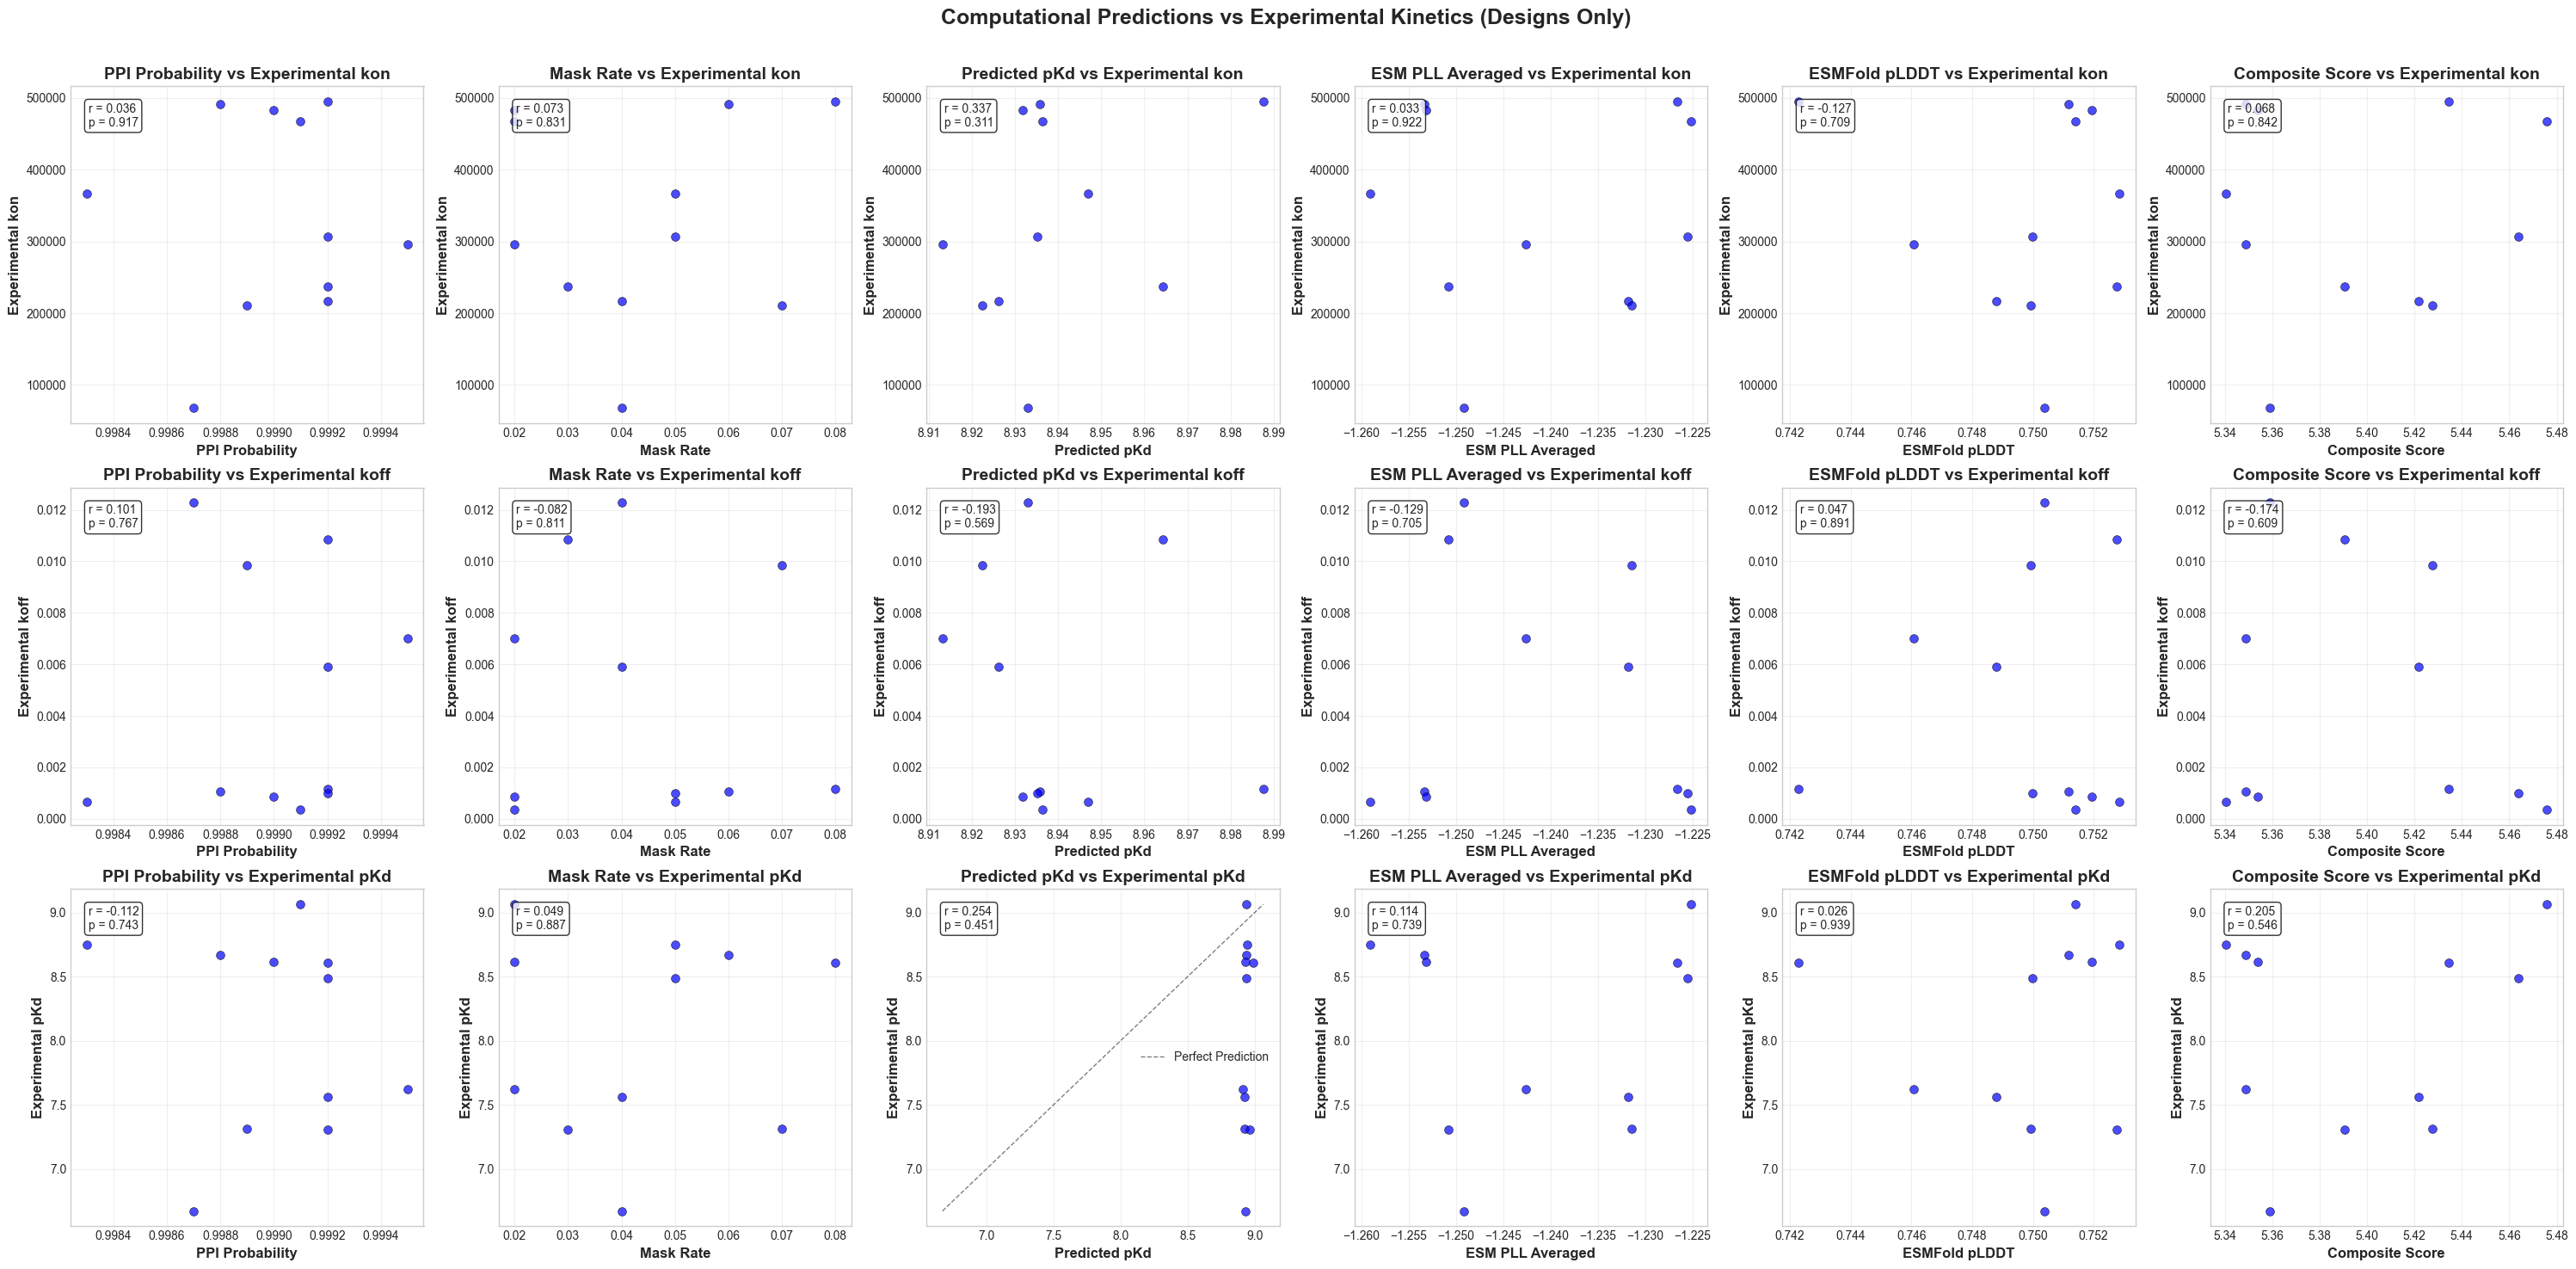

Summary Statistics (Designs Only):
Number of sequences with experimental data: 11
Experimental pKd range: 6.67 - 9.06
Experimental kon range: 6.76e+04 - 4.95e+05
Experimental koff range: 3.62e-04 - 1.23e-02
PPI Probability range: 0.9983 - 0.9995
Mask Rate range: 0.0200 - 0.0800
Predicted pKd range: 8.9132 - 8.9876
ESM PLL Averaged range: -1.2591 - -1.2251
ESMFold pLDDT range: 0.7423 - 0.7528
Composite Score range: 5.3406 - 5.4759

Correlation coefficients (r, p):
PPI Probability vs Experimental kon: r = 0.036, p = 0.917
Mask Rate vs Experimental kon: r = 0.073, p = 0.831
Predicted pKd vs Experimental kon: r = 0.337, p = 0.311
ESM PLL Averaged vs Experimental kon: r = 0.033, p = 0.922
ESMFold pLDDT vs Experimental kon: r = -0.127, p = 0.709
Composite Score vs Experimental kon: r = 0.068, p = 0.842
PPI Probability vs Experimental koff: r = 0.101, p = 0.767
Mask Rate vs Experimental koff: r = -0.082, p = 0.811
Predicted pKd vs Experimental koff: r = -0.193, p = 0.569
ESM PLL Averaged vs E

In [20]:
### Plots: ignore template, simplify, add more columns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Columns to include in analysis
cols = [
    'pkd', 'ppi-probability', 'predicted-pkd', 'mask-rate',
    'esm_pll_averaged', 'esmfold_plddt', 'composite_score'
]

# Ensure numeric and drop rows with missing values in any of the columns of interest
for col in cols + ['kon', 'koff']:
    egfr[col] = pd.to_numeric(egfr[col], errors='coerce')

# Exclude template from analysis
plot_data = egfr[(egfr['name'] != 'template')].dropna(subset=cols + ['kon', 'koff']).copy()

# Plot settings
plot_pairs = [
    ('ppi-probability', 'PPI Probability'),
    ('mask-rate', 'Mask Rate'),
    ('predicted-pkd', 'Predicted pKd'),
    ('esm_pll_averaged', 'ESM PLL Averaged'),
    ('esmfold_plddt', 'ESMFold pLDDT'),
    ('composite_score', 'Composite Score')
]

n_rows = 3
n_cols = 6
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
fig.suptitle('Computational Predictions vs Experimental Kinetics (Designs Only)', fontsize=18, fontweight='bold')

# Prepare y-axis variables and their labels
ycols = [
    ('kon', 'Experimental kon'),
    ('koff', 'Experimental koff'),
    ('pkd', 'Experimental pKd')
]

for row_idx, (ycol, ylabel) in enumerate(ycols):
    for col_idx, (xcol, xlabel) in enumerate(plot_pairs):
        ax = axes[row_idx, col_idx]
        ax.scatter(plot_data[xcol], plot_data[ycol], c='blue', s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
        ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
        ax.set_title(f'{xlabel} vs {ylabel}', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        # Add diagonal for predicted-pkd vs pkd
        if xcol == 'predicted-pkd' and ycol == 'pkd':
            min_val = min(plot_data[xcol].min(), plot_data[ycol].min())
            max_val = max(plot_data[xcol].max(), plot_data[ycol].max())
            ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, linewidth=1, label='Perfect Prediction')
            ax.legend()
        # Add correlation
        if len(plot_data) > 2:
            try:
                r, p = stats.pearsonr(plot_data[xcol], plot_data[ycol])
                ax.text(0.05, 0.95, f'r = {r:.3f}\np = {p:.3f}',
                        transform=ax.transAxes, fontsize=10, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            except Exception as e:
                ax.text(0.05, 0.95, f'Error: {e}', transform=ax.transAxes, fontsize=8, verticalalignment='top')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig('egfr.png', dpi=300)
plt.show()

# Print summary statistics
print("Summary Statistics (Designs Only):")
print(f"Number of sequences with experimental data: {len(plot_data)}")
print(f"Experimental pKd range: {plot_data['pkd'].min():.2f} - {plot_data['pkd'].max():.2f}")
print(f"Experimental kon range: {plot_data['kon'].min():.2e} - {plot_data['kon'].max():.2e}")
print(f"Experimental koff range: {plot_data['koff'].min():.2e} - {plot_data['koff'].max():.2e}")
for xcol, xlabel in plot_pairs:
    print(f"{xlabel} range: {plot_data[xcol].min():.4f} - {plot_data[xcol].max():.4f}")

if len(plot_data) > 2:
    print(f"\nCorrelation coefficients (r, p):")
    for ycol, ylabel in ycols:
        for xcol, xlabel in plot_pairs:
            try:
                r, p = stats.pearsonr(plot_data[xcol], plot_data[ycol])
                print(f"{xlabel} vs {ylabel}: r = {r:.3f}, p = {p:.3f}")
            except Exception as e:
                print(f"{xlabel} vs {ylabel}: Error: {e}")


In [23]:
df = pd.read_excel('egfr_results.xlsx')
# sort by pkd column
df = df.sort_values(by='pkd', ascending=False)
names = df['name']
sequences = df['sequence']
# write to fasta file
with open('egfr.fasta', 'w') as f:
    for name, sequence in zip(names, sequences):
        f.write(f'>{name}\n{sequence}\n')

In [25]:
# find the site differences between template and the top design
template_seq = template['sequence']
best_seq = df.iloc[0]['sequence']

# Compare the two sequences and print the positions and residues that differ
diffs = []
for i, (t_res, b_res) in enumerate(zip(template_seq, best_seq), 1):
    if t_res != b_res:
        diffs.append((i, t_res, b_res))

print("Site differences between template and top design:")
for pos, t_res, b_res in diffs:
    # Get the context window in the best_seq (5 residues before and after, 1-based)
    start = max(0, pos - 6)  # -6 because pos is 1-based, and we want 5 before
    end = min(len(best_seq), pos + 5)  # up to 5 after
    context = best_seq[start:end]
    # Mark the mutated residue in the context with brackets
    rel_mut_idx = pos - 1 - start  # index of the mutated residue in the context string
    if 0 <= rel_mut_idx < len(context):
        context_with_mut = (
            context[:rel_mut_idx] + "[" + context[rel_mut_idx] + "]" + context[rel_mut_idx+1:]
        )
    else:
        context_with_mut = context
    print(f"Position {pos}: template={t_res} -> design={b_res} | context: {context_with_mut}")


Site differences between template and top design:
Position 92: template=I -> design=V | context: TDDTA[V]YYCAR
Position 165: template=T -> design=S | context: SQSIG[S]NIHWY
Position 240: template=L -> design=I | context: GTKLE[I]K
